In [3]:
import pandas as pd

# Correcting the filename to match the file in /content/
df = pd.read_csv('/content/Sample - Superstore.csv', encoding='latin1')
display(df.head())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
# 1. Statistical Summary
print("Dataset Info:")
display(df.info())

print("\nNumerical Summary:")
display(df.describe())

print("\nMissing Values:")
display(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64

None


Numerical Summary:


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000



Missing Values:


,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


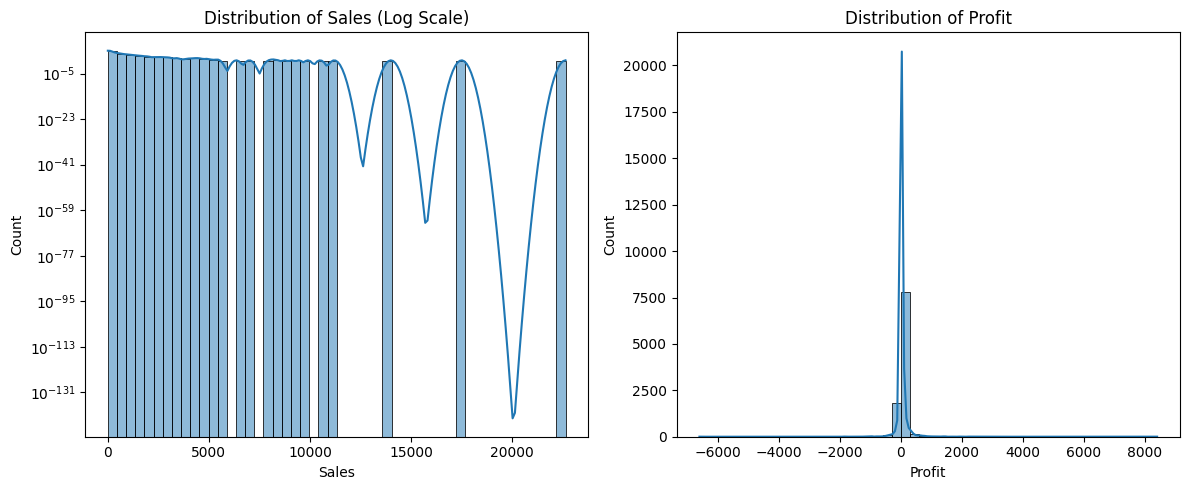

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Visualizing Distributions
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Sales'], bins=50, kde=True)
plt.title('Distribution of Sales (Log Scale)')
plt.yscale('log')

plt.subplot(1, 2, 2)
sns.histplot(df['Profit'], bins=50, kde=True)
plt.title('Distribution of Profit')

plt.tight_layout()
plt.show()

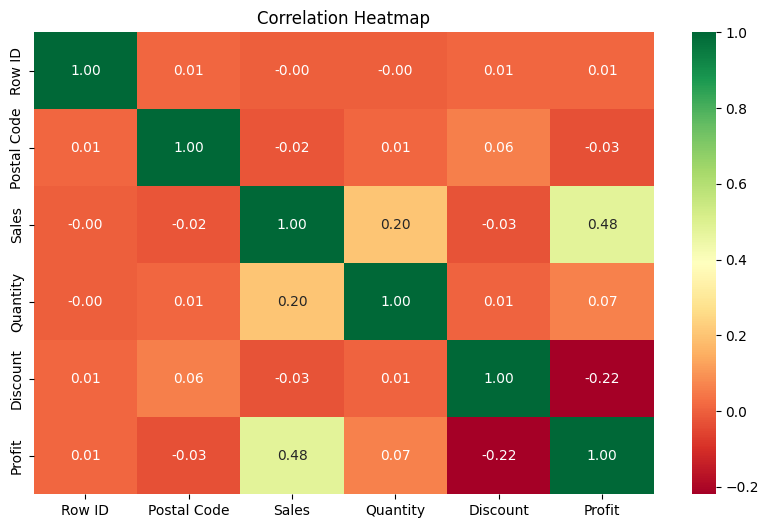

In [8]:
# 3. Correlation Analysis
plt.figure(figsize=(10, 6))
# Filtering only numeric columns for correlation
numeric_df = df.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

/tmp/ipykernel_1970/771093746.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Sales', data=df, estimator=sum, errorbar=None, palette='viridis')
/tmp/ipykernel_1970/771093746.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Profit', data=df, estimator=sum, errorbar=None, palette='magma')


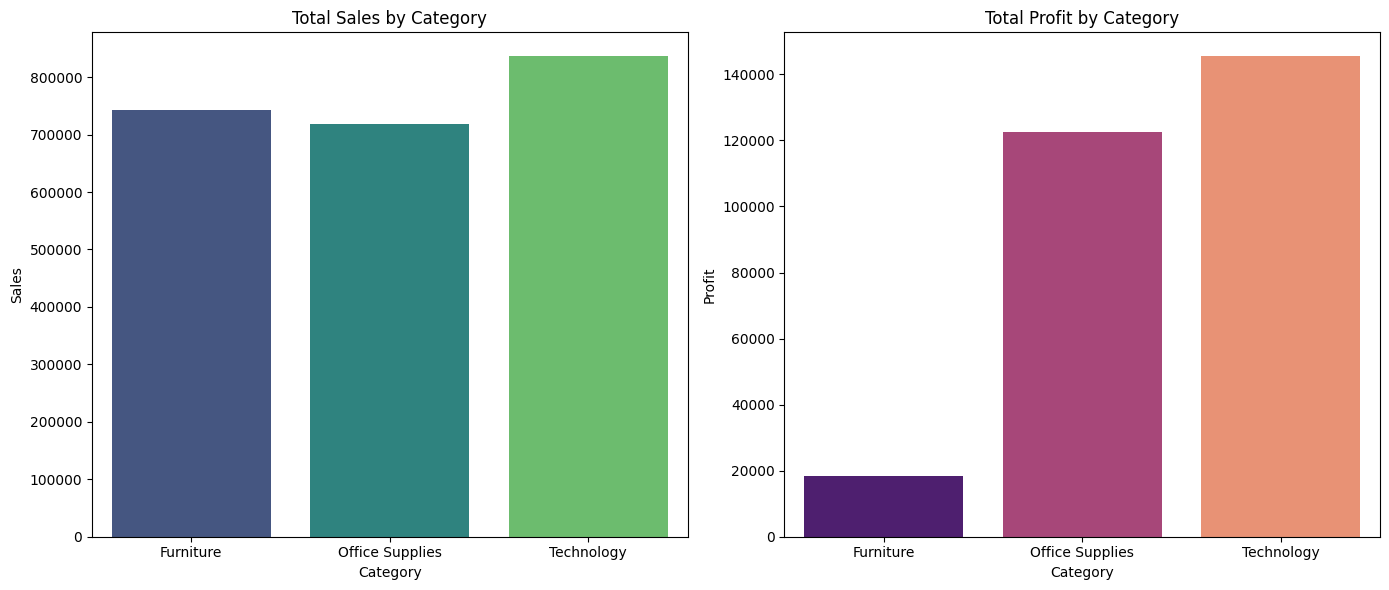

In [13]:
# 4. Category-wise Analysis
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.barplot(x='Category', y='Sales', data=df, estimator=sum, errorbar=None, palette='viridis')
plt.title('Total Sales by Category')

plt.subplot(1, 2, 2)
sns.barplot(x='Category', y='Profit', data=df, estimator=sum, errorbar=None, palette='magma')
plt.title('Total Profit by Category')

plt.tight_layout()
plt.show()

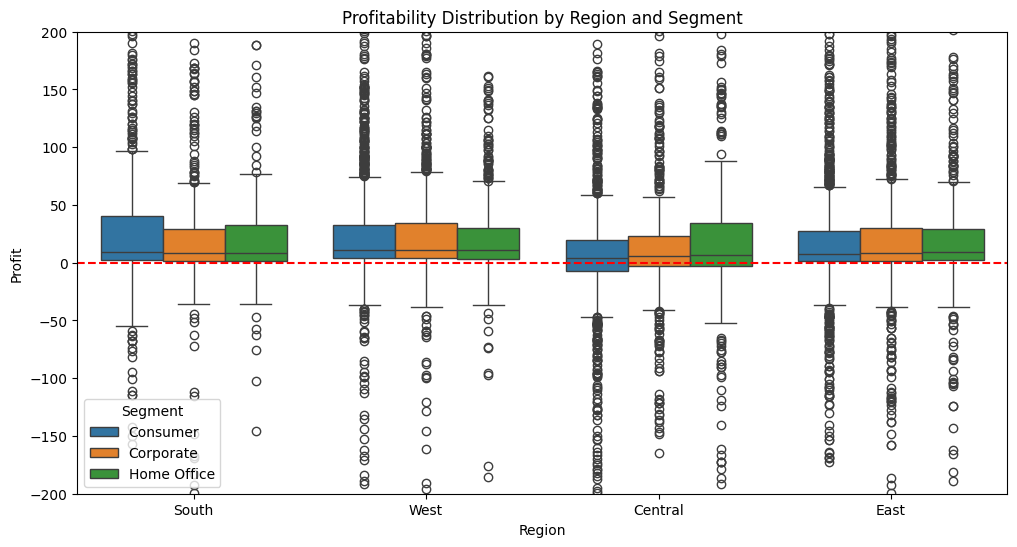

In [14]:
# 5. Identifying Key Influencing Factors: Profit by Segment and Region
plt.figure(figsize=(12, 6))
sns.boxplot(x='Region', y='Profit', hue='Segment', data=df)
plt.ylim(-200, 200) # Zooming in to see the bulk of the distribution
plt.title('Profitability Distribution by Region and Segment')
plt.axhline(0, color='red', linestyle='--')
plt.show()

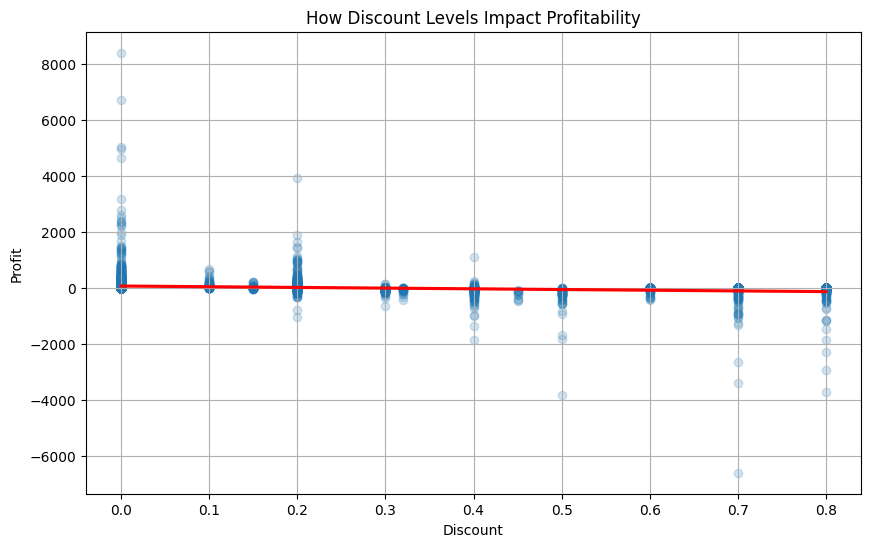

--- PROJECT SUMMARY REPORT ---
Total Sales: 2,297,200.86
Total Profit: 286,397.02
Average Discount: 0.16
Most Profitable Category: Technology
Least Profitable Region: Central


In [20]:
# Final Project Summary: Key Influencing Factors
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the impact of Discounts on Profit
plt.figure(figsize=(10, 6))
sns.regplot(x='Discount', y='Profit', data=df, scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
plt.title('How Discount Levels Impact Profitability')
plt.grid(True)
plt.show()

# Structured Summary Report
summary = {
    'Total Sales': df['Sales'].sum(),
    'Total Profit': df['Profit'].sum(),
    'Average Discount': df['Discount'].mean(),
    'Most Profitable Category': df.groupby('Category')['Profit'].sum().idxmax(),
    'Least Profitable Region': df.groupby('Region')['Profit'].sum().idxmin()
}

print("--- PROJECT SUMMARY REPORT ---")
for key, value in summary.items():
    if isinstance(value, float):
        print(f"{key}: {value:,.2f}")
    else:
        print(f"{key}: {value}")

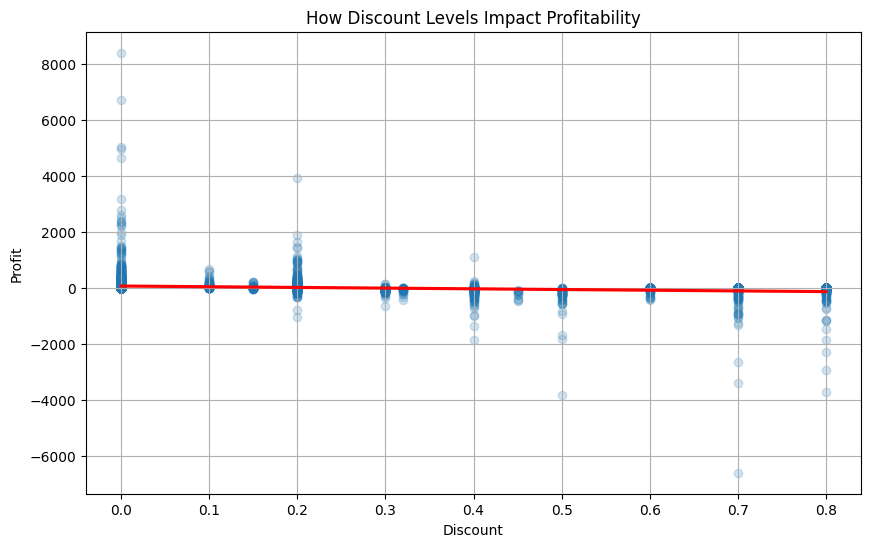

--- PROJECT SUMMARY REPORT ---
Total Sales: 2,297,200.86
Total Profit: 286,397.02
Average Discount: 0.16
Most Profitable Category: Technology
Least Profitable Region: Central


In [19]:
# Final Project Summary: Key Influencing Factors
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the impact of Discounts on Profit
plt.figure(figsize=(10, 6))
sns.regplot(x='Discount', y='Profit', data=df, scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
plt.title('How Discount Levels Impact Profitability')
plt.grid(True)
plt.show()

# Structured Summary Report
summary = {
    'Total Sales': df['Sales'].sum(),
    'Total Profit': df['Profit'].sum(),
    'Average Discount': df['Discount'].mean(),
    'Most Profitable Category': df.groupby('Category')['Profit'].sum().idxmax(),
    'Least Profitable Region': df.groupby('Region')['Profit'].sum().idxmin()
}

print("--- PROJECT SUMMARY REPORT ---")
for key, value in summary.items():
    if isinstance(value, float):
        print(f"{key}: {value:,.2f}")
    else:
        print(f"{key}: {value}")

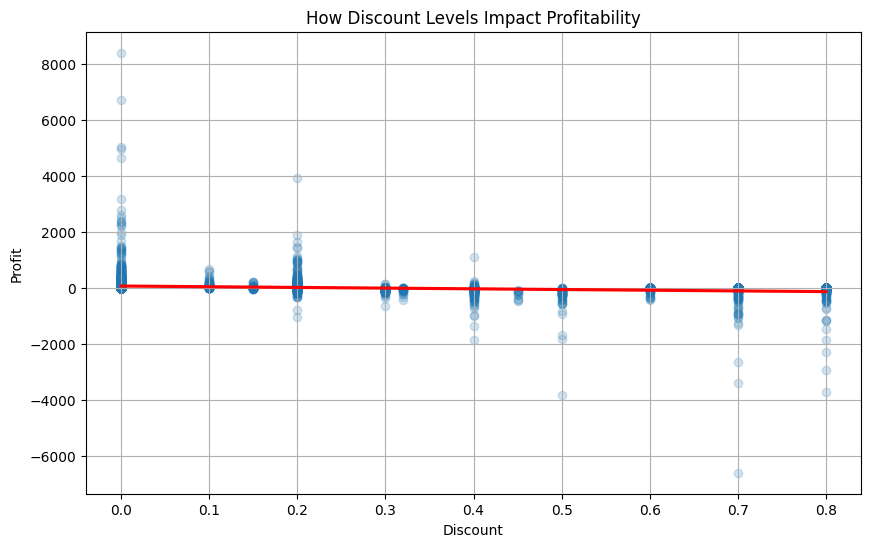

--- PROJECT SUMMARY REPORT ---
Total Sales: 2,297,200.86
Total Profit: 286,397.02
Average Discount: 0.16
Most Profitable Category: Technology
Least Profitable Region: Central


In [18]:
# Final Project Summary: Key Influencing Factors
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the impact of Discounts on Profit
plt.figure(figsize=(10, 6))
sns.regplot(x='Discount', y='Profit', data=df, scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
plt.title('How Discount Levels Impact Profitability')
plt.grid(True)
plt.show()

# Structured Summary Report
summary = {
    'Total Sales': df['Sales'].sum(),
    'Total Profit': df['Profit'].sum(),
    'Average Discount': df['Discount'].mean(),
    'Most Profitable Category': df.groupby('Category')['Profit'].sum().idxmax(),
    'Least Profitable Region': df.groupby('Region')['Profit'].sum().idxmin()
}

print("--- PROJECT SUMMARY REPORT ---")
for key, value in summary.items():
    if isinstance(value, float):
        print(f"{key}: {value:,.2f}")
    else:
        print(f"{key}: {value}")

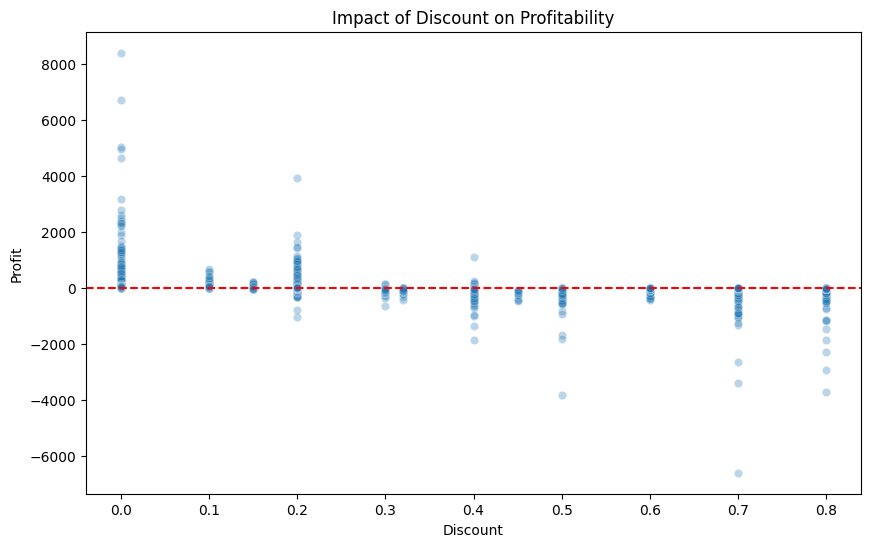

Project Insights Summary:
Total Sales: $2,297,200.86
Total Profit: $286,397.02
Average Discount: 15.62%


In [17]:
# Project 4: Identifying Influencing Factors
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Discount', y='Profit', data=df, alpha=0.3)
plt.title('Impact of Discount on Profitability')
plt.axhline(0, color='red', linestyle='--')
plt.show()

# Summary report calculation
print('Project Insights Summary:')
print(f"Total Sales: ${df['Sales'].sum():,.2f}")
print(f"Total Profit: ${df['Profit'].sum():,.2f}")
print(f"Average Discount: {df['Discount'].mean():.2%}")

/tmp/ipykernel_1970/1712438927.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_trends = df.resample('M', on='Order Date')[['Sales', 'Profit']].sum()


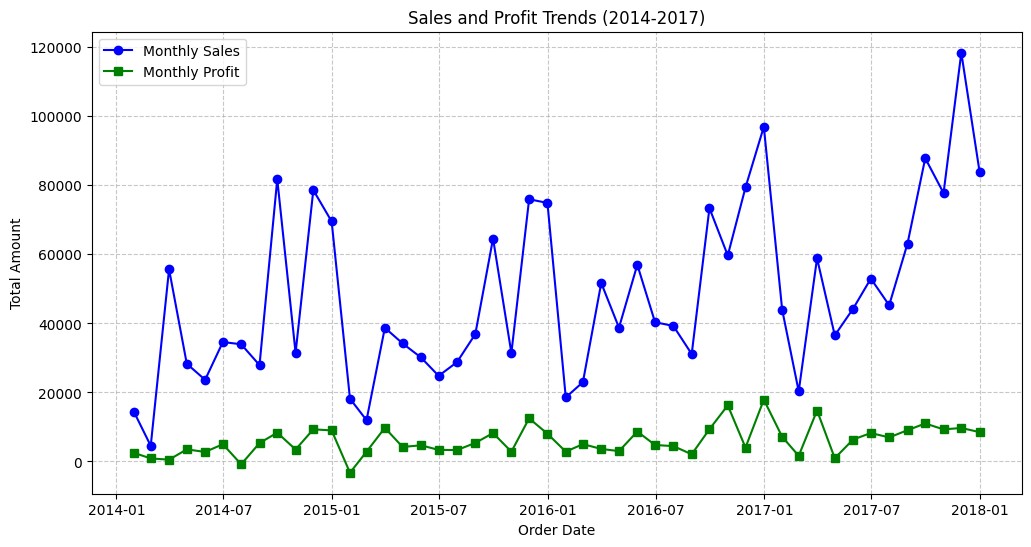

In [16]:
# Project 4: Time Series & Trend Analysis
# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Group by month and sum the Sales and Profit
monthly_trends = df.resample('M', on='Order Date')[['Sales', 'Profit']].sum()

plt.figure(figsize=(12, 6))
plt.plot(monthly_trends.index, monthly_trends['Sales'], label='Monthly Sales', marker='o', color='blue')
plt.plot(monthly_trends.index, monthly_trends['Profit'], label='Monthly Profit', marker='s', color='green')
plt.title('Sales and Profit Trends (2014-2017)')
plt.xlabel('Order Date')
plt.ylabel('Total Amount')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_1970/821556547.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample('M', on='Order Date')['Sales'].sum()
/tmp/ipykernel_1970/821556547.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_profit = df.resample('M', on='Order Date')['Profit'].sum()


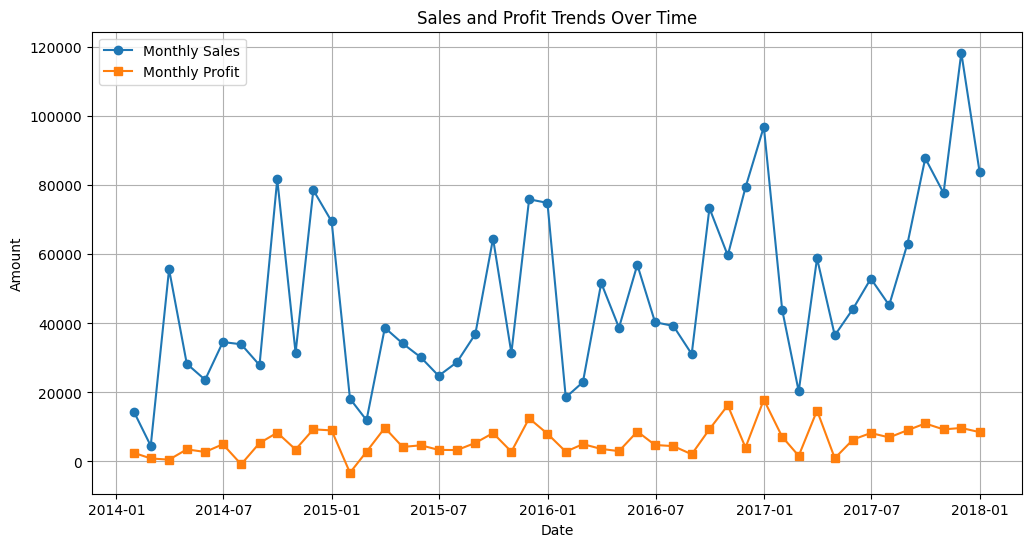

In [15]:
# Project 4: Time Series & Trend Analysis
# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Group by month
monthly_sales = df.resample('M', on='Order Date')['Sales'].sum()
monthly_profit = df.resample('M', on='Order Date')['Profit'].sum()

plt.figure(figsize=(12, 6))
plt.plot(monthly_sales, label='Monthly Sales', marker='o')
plt.plot(monthly_profit, label='Monthly Profit', marker='s')
plt.title('Sales and Profit Trends Over Time')
plt.xlabel('Date')
plt.ylabel('Amount')
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_1970/2990359502.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Sales', data=df, estimator=sum, errorbar=None, palette='viridis')
/tmp/ipykernel_1970/2990359502.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Profit', data=df, estimator=sum, errorbar=None, palette='magma')


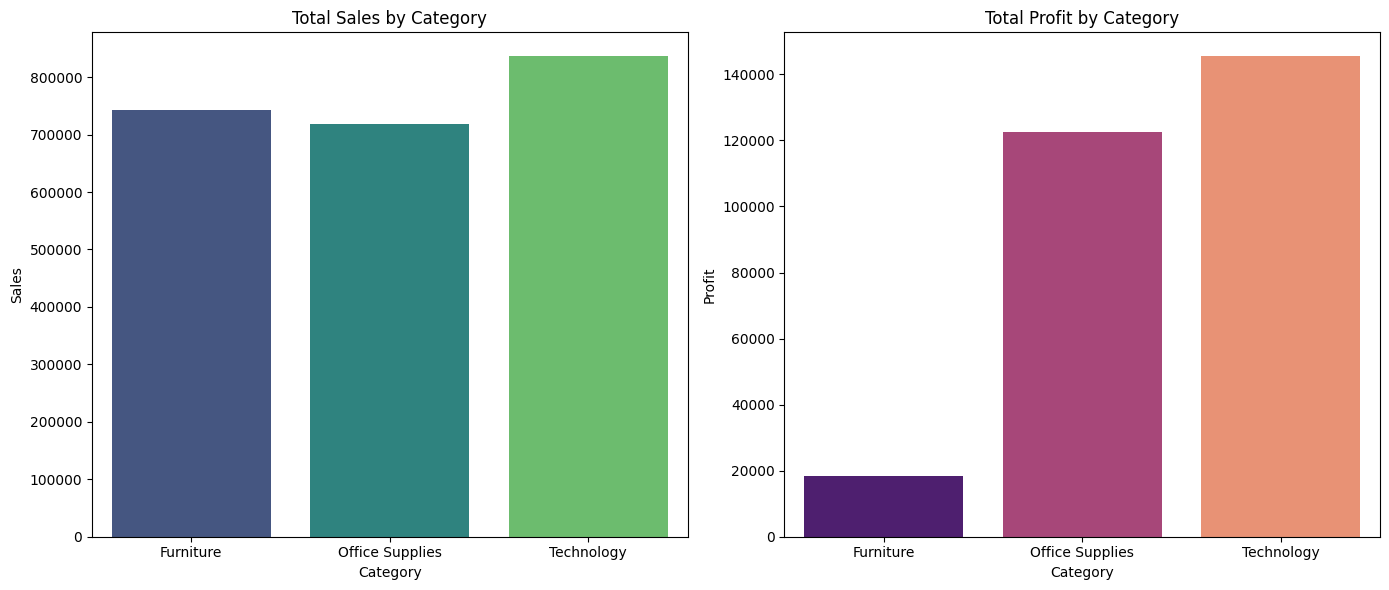

In [11]:
# 4. Category-wise Analysis
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.barplot(x='Category', y='Sales', data=df, estimator=sum, errorbar=None, palette='viridis')
plt.title('Total Sales by Category')

plt.subplot(1, 2, 2)
sns.barplot(x='Category', y='Profit', data=df, estimator=sum, errorbar=None, palette='magma')
plt.title('Total Profit by Category')

plt.tight_layout()
plt.show()

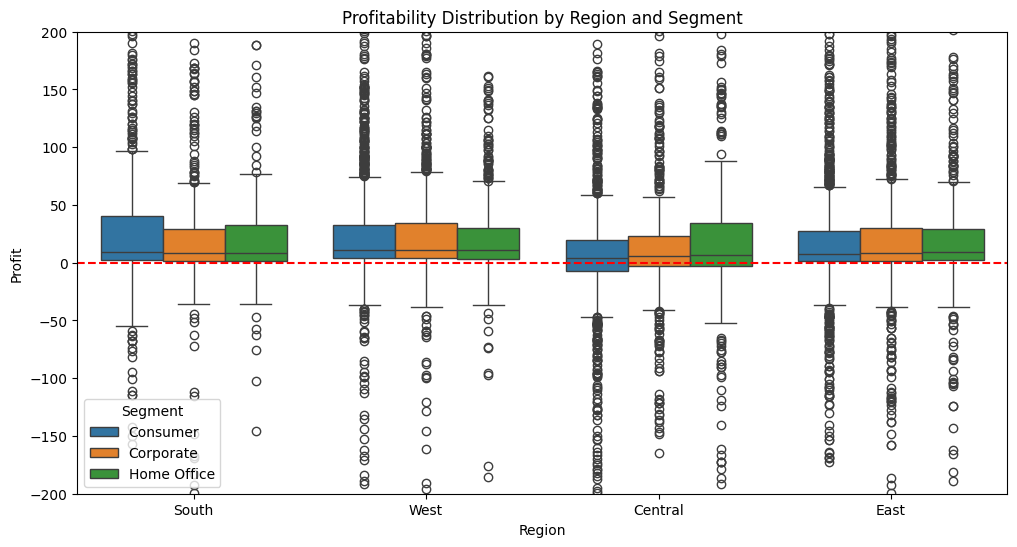

In [12]:
# 5. Identifying Key Influencing Factors: Profit by Segment and Region
plt.figure(figsize=(12, 6))
sns.boxplot(x='Region', y='Profit', hue='Segment', data=df)
plt.ylim(-200, 200) # Zooming in to see the bulk of the distribution
plt.title('Profitability Distribution by Region and Segment')
plt.axhline(0, color='red', linestyle='--')
plt.show()

/tmp/ipykernel_1970/4265196754.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Category', y='Sales', data=df, estimator=sum, ci=None, palette='viridis')
/tmp/ipykernel_1970/4265196754.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Sales', data=df, estimator=sum, ci=None, palette='viridis')
/tmp/ipykernel_1970/4265196754.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Category', y='Profit', data=df, estimator=sum, ci=None, palette='magma')
/tmp/ipykernel_1970/4265196754.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', 

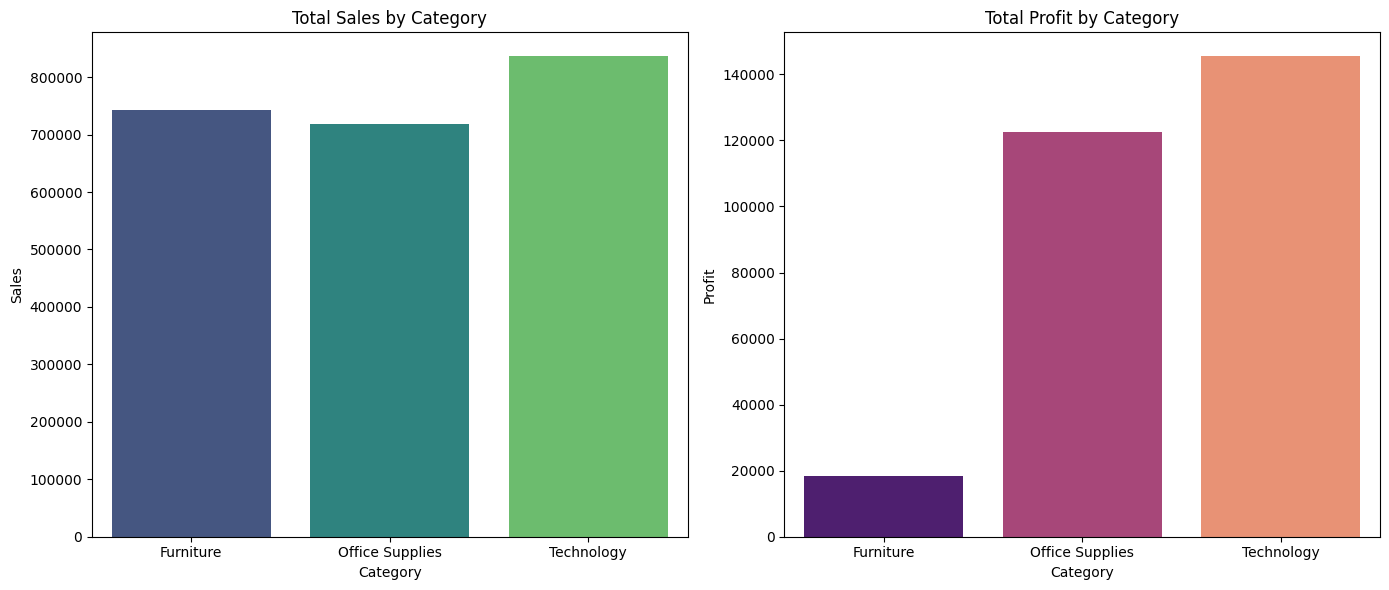

In [9]:
# 4. Category-wise Analysis
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.barplot(x='Category', y='Sales', data=df, estimator=sum, ci=None, palette='viridis')
plt.title('Total Sales by Category')

plt.subplot(1, 2, 2)
sns.barplot(x='Category', y='Profit', data=df, estimator=sum, ci=None, palette='magma')
plt.title('Total Profit by Category')

plt.tight_layout()
plt.show()

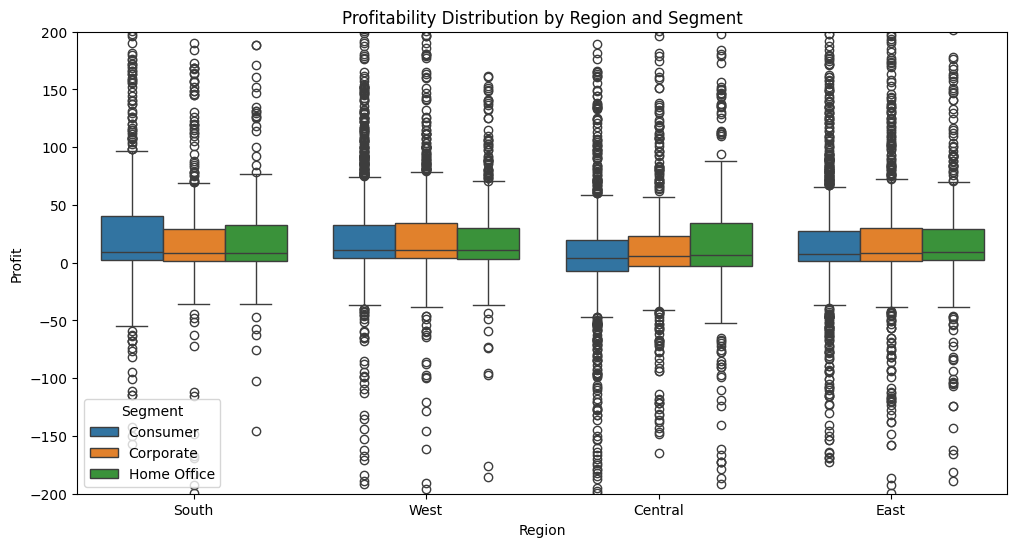

In [10]:
# 5. Identifying Key Influencing Factors: Profit by Segment and Region
plt.figure(figsize=(12, 6))
sns.boxplot(x='Region', y='Profit', hue='Segment', data=df)
plt.ylim(-200, 200) # Zooming in to see the bulk of the data
plt.title('Profitability Distribution by Region and Segment')
plt.show()

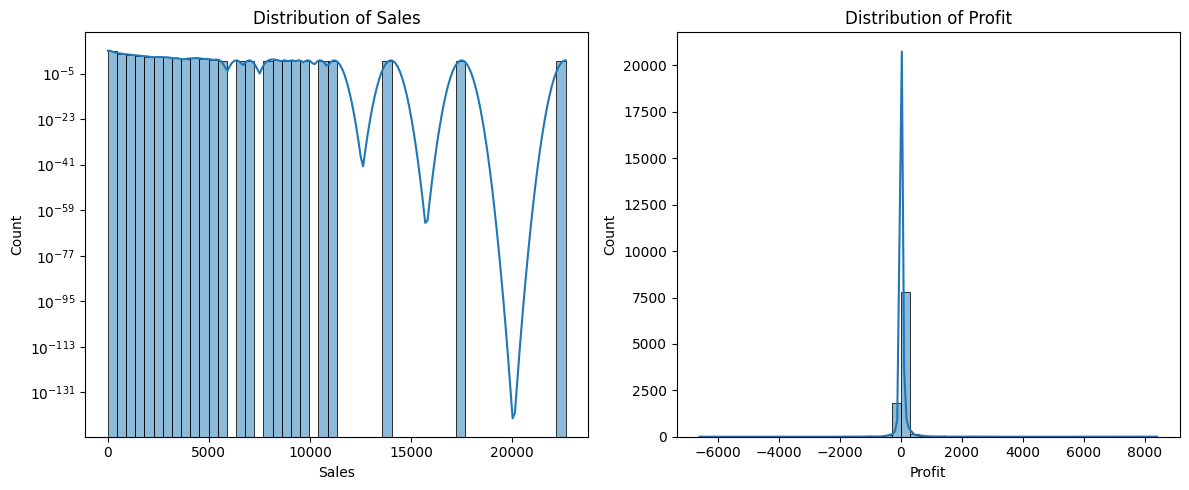

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Visualizing Distributions
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Sales'], bins=50, kde=True)
plt.title('Distribution of Sales')
plt.yscale('log') # Log scale to handle outliers

plt.subplot(1, 2, 2)
sns.histplot(df['Profit'], bins=50, kde=True)
plt.title('Distribution of Profit')

plt.tight_layout()
plt.show()

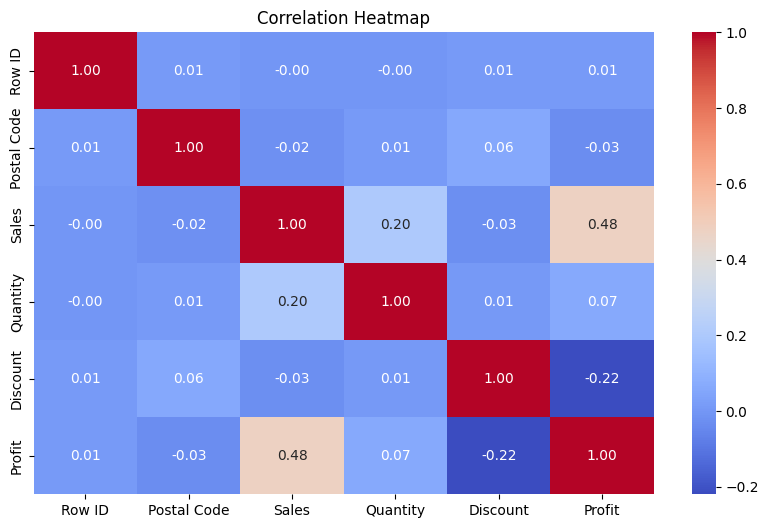

In [6]:
# 3. Correlation Analysis
plt.figure(figsize=(10, 6))
correlation_matrix = df.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()